In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

In [4]:
df.head()


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [6]:
df.shape


(1200, 14)

In [7]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [8]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df["Date"] = pd.to_datetime(df["Date"])

In [15]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Day"] = df["Date"].dt.day

In [16]:
df.select_dtypes(include="object").columns

C:\Users\Josemila\AppData\Local\Temp\ipykernel_24588\1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod',
       'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource'],
      dtype='str')

In [17]:
encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

C:\Users\Josemila\AppData\Local\Temp\ipykernel_24588\4027654945.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [18]:
df = df.drop(["OrderID","TrackingNumber"], axis=1)

In [21]:
df_numeric = df.select_dtypes(include=['number'])

scaled_data = scaler.fit_transform(df_numeric)

In [22]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [23]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1","PC2"]
)

In [24]:
wcss=[]

for i in range(2,11):

    model=KMeans(n_clusters=i,random_state=42)

    model.fit(pca_data)

    wcss.append(model.inertia_)

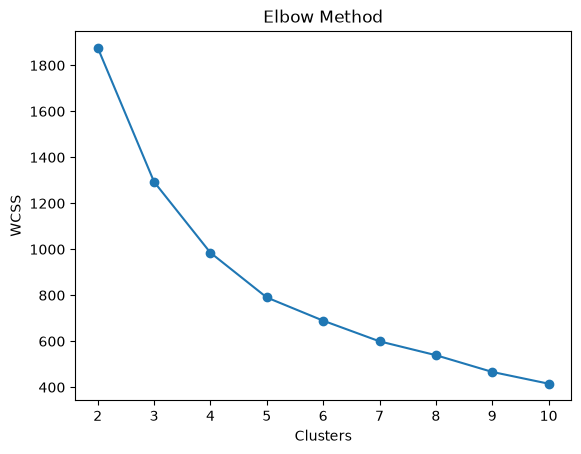

In [25]:
plt.plot(range(2,11),wcss,marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [26]:
for i in range(2,11):

    model=KMeans(n_clusters=i,random_state=42)

    labels=model.fit_predict(pca_data)

    score=silhouette_score(pca_data,labels)

    print(i,score)

2 0.38446586219461987
3 0.36521725863582233
4 0.3557721758024373
5 0.35172698942574065
6 0.33851831736708177
7 0.33363735292572505
8 0.3221942473013909
9 0.3341638107889942
10 0.34385027373211297


In [27]:
kmeans=KMeans(
    n_clusters=4,
    random_state=42
)

clusters=kmeans.fit_predict(pca_data)

pca_df["Cluster"]=clusters

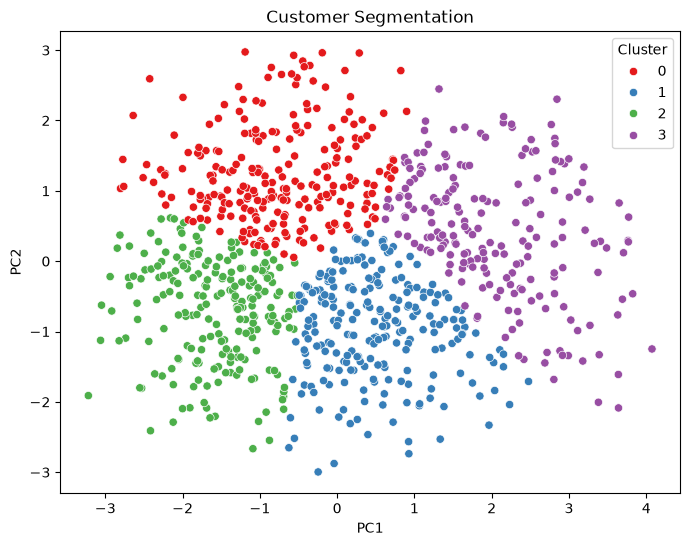

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Segmentation")
plt.show()

In [32]:
plt.savefig("customer_segmentation.png")

<Figure size 640x480 with 0 Axes>

In [29]:
df["Cluster"]=clusters

In [30]:
df.groupby("Cluster").mean()

,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day
Cluster,,,,,,,,,,,,,,,
0,2024-08-14 01:53:31.618257,480.323651,3.165975,2.066390,365.256390,314.618257,2.356846,1.983402,4.369295,0.892116,2.497925,672.500747,2024.352697,3.742739,15.012448
1,2023-12-02 22:21:57.446808,410.463830,2.812766,3.689362,341.279702,243.157447,1.685106,1.906383,6.425532,1.004255,1.621277,1151.439106,2023.331915,7.536170,17.523404
2,2024-01-20 16:26:40.000000,379.953704,2.972222,1.699074,238.003565,266.444444,1.939815,1.986111,3.879630,1.064815,1.666667,346.121157,2023.421296,8.115741,15.870370
3,2024-04-26 07:21:24.422110,504.653266,3.145729,4.331658,510.831608,283.060302,1.959799,1.894472,7.351759,0.949749,2.060302,2185.615628,2023.964824,4.768844,15.783920


In [31]:
df.groupby("Cluster").size()

Cluster
0    241
1    235
2    216
3    199
dtype: int64

In [35]:
cluster_summary = df.groupby("Cluster").agg({
    "Quantity": "mean",
    "UnitPrice": "mean",
    "TotalPrice": "mean"
}).round(2)

print("Cluster Summary")
print(cluster_summary)

Cluster Summary
         Quantity  UnitPrice  TotalPrice
Cluster                                 
0            2.07     365.26      672.50
1            3.69     341.28     1151.44
2            1.70     238.00      346.12
3            4.33     510.83     2185.62


In [36]:
highest_spending = cluster_summary["TotalPrice"].idxmax()
lowest_spending = cluster_summary["TotalPrice"].idxmin()


In [37]:
persona_map = {}


In [38]:
for cluster in cluster_summary.index:

    if cluster == highest_spending:
        persona_map[cluster] = "Premium Customers"

    elif cluster == lowest_spending:
        persona_map[cluster] = "Budget Customers"

    else:
        if cluster_summary.loc[cluster, "Quantity"] >= cluster_summary["Quantity"].mean():
            persona_map[cluster] = "Regular Customers"
        else:
            persona_map[cluster] = "Occasional Buyers"

In [39]:
df["Persona"] = df["Cluster"].map(persona_map)


In [40]:
print("\nCustomer Personas")
print(df[["Cluster", "Persona"]].drop_duplicates().sort_values("Cluster"))


Customer Personas
   Cluster            Persona
1        0  Occasional Buyers
7        1  Regular Customers
3        2   Budget Customers
0        3  Premium Customers


In [41]:
print("\nUpdated Dataset")
print(df.head())


Updated Dataset
        Date  CustomerID  Product  Quantity  UnitPrice  ShippingAddress  \
0 2023-01-04         632        3         5     570.62              505   
1 2024-08-23         655        4         2     151.35              435   
2 2024-02-27         707        6         5     550.68              247   
3 2023-10-15         250        0         1     273.19              103   
4 2025-05-08         708        5         4     626.01              343   

   PaymentMethod  OrderStatus  ItemsInCart  CouponCode  ReferralSource  \
0              2            4            7           1               3   
1              4            4            3           1               4   
2              1            0            8           0               0   
3              2            3            5           1               1   
4              4            1            8           1               0   

   TotalPrice  Year  Month  Day  Cluster            Persona  
0     2853.10  2023      

In [42]:
persona_count = df["Persona"].value_counts()

print(persona_count)

Persona
Occasional Buyers    241
Regular Customers    235
Budget Customers     216
Premium Customers    199
Name: count, dtype: int64


In [43]:
cluster_summary["Persona"] = cluster_summary.index.map(persona_map)

print(cluster_summary)

         Quantity  UnitPrice  TotalPrice            Persona
Cluster                                                    
0            2.07     365.26      672.50  Occasional Buyers
1            3.69     341.28     1151.44  Regular Customers
2            1.70     238.00      346.12   Budget Customers
3            4.33     510.83     2185.62  Premium Customers


In [44]:
df.to_excel("Customer_Segmentation_Final.xlsx", index=False)

print("Project saved successfully!")

Project saved successfully!


In [45]:
recommendations = {
    "Premium Customers": "Provide VIP membership, exclusive discounts, and premium support.",
    "Regular Customers": "Offer loyalty points and personalized product recommendations.",
    "Occasional Buyers": "Send reminder emails and seasonal offers to increase purchases.",
    "Budget Customers": "Provide coupons, bundle deals, and promotional discounts."
}

for persona, recommendation in recommendations.items():
    print(f"\n{persona}")
    print(recommendation)


Premium Customers
Provide VIP membership, exclusive discounts, and premium support.

Regular Customers
Offer loyalty points and personalized product recommendations.

Occasional Buyers
Send reminder emails and seasonal offers to increase purchases.

Budget Customers
Provide coupons, bundle deals, and promotional discounts.
